# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam271/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research question

Can a machine-learning scoring model help an SEO/content team prioritize which content pages should be reviewed first for possible refresh, using observable performance and content signals?

### Decision supported

The model produces a **priority score** for human review. It is intended to help the team decide **which pages to review first**, not to automatically decide that a page should be refreshed or to guarantee a performance improvement.

### Task

This is a **binary classification and ranking** problem. The proxy label marks pages whose observed `trend_direction` is `"down"`. The model estimates the likelihood of this proxy condition and uses that score to rank pages for review.

### Success metric

The main evaluation metric is **Precision@50**: among the 50 highest-priority pages, how many have the declining proxy label?

This metric matches the practical decision because the team has limited review capacity and needs a focused top-of-queue list.


In [8]:
# Define the research question, decision, task, target, and evaluation metric.

RESEARCH_QUESTION = (
    "Can a machine-learning scoring model help an SEO/content team "
    "prioritize which content pages should be reviewed first for possible refresh, "
    "using observable performance and content signals?"
)

DECISION = "Prioritize content pages for human review."

TASK_TYPE = "Binary classification and ranking"

TARGET_DEFINITION = 'trend_direction == "down"'

METRIC = "Precision@50"

DECISION_USE = "Decision-support, not automatic refresh or guaranteed performance improvement."

print("Research question:")
print(RESEARCH_QUESTION)

print("\nDecision:")
print(DECISION)

print("\nTask type:")
print(TASK_TYPE)

print("\nTarget/proxy:")
print(TARGET_DEFINITION)

print("\nSuccess metric:")
print(METRIC)

print("\nDecision use:")
print(DECISION_USE)

# Basic self-checks
assert TASK_TYPE == "Binary classification and ranking"
assert TARGET_DEFINITION == 'trend_direction == "down"'
assert METRIC == "Precision@50"

Research question:
Can a machine-learning scoring model help an SEO/content team prioritize which content pages should be reviewed first for possible refresh, using observable performance and content signals?

Decision:
Prioritize content pages for human review.

Task type:
Binary classification and ranking

Target/proxy:
trend_direction == "down"

Success metric:
Precision@50

Decision use:
Decision-support, not automatic refresh or guaranteed performance improvement.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Data

This capstone uses two complementary data sources from the FlyRank ML Internship work.

**1. Content-level modeling data**

The anonymized content dataset was used for the signal audit and logistic-regression model. It contains observable content and performance signals such as impressions, clicks, sessions, CTR, average position, content age, freshness, and recent-versus-previous performance.

The modeling unit is **one content page**.

The proxy label is derived from the observed `trend_direction` field. A page is labeled positive when `trend_direction == "down"`.

**2. Full warehouse data**

The March 2026 warehouse release was used for the data-contract and baseline analysis. The relevant tables were:

* `dim_clients.parquet`
* `dim_content.parquet`
* `fact_content_daily_performance`

The March 2026 performance slice contains **9,841,378 rows**, covering **2026-03-01 through 2026-03-31**. The documented warehouse grain is one content page for one client on one report date.

Available performance fields included Google Search Console and Google Analytics 4 signals such as impressions, clicks, average position, pageviews, and sessions.

### Exclusions and safety

Future or outcome-derived fields were excluded from modeling to reduce leakage risk. Client names, domains, URLs, private queries, credentials, and raw private exports are not used in the public analysis.

A leakage check in the data-contract work showed that an artificial outcome-derived feature could produce an unrealistically perfect result, demonstrating why such fields must be excluded.

The analysis is therefore framed as **directional decision-support**, not as proof of causal refresh impact or a prediction of Google's ranking algorithm.


In [9]:
# Record the documented data sources and perform basic consistency checks.

WAREHOUSE_DATASET = "hf://datasets/FlyRank/internship-warehouse"

WAREHOUSE_TABLES = [
    "dim_clients.parquet",
    "dim_content.parquet",
    "fact_content_daily_performance",
]

WAREHOUSE_MONTH = "March 2026"
WAREHOUSE_START = "2026-03-01"
WAREHOUSE_END = "2026-03-31"
WAREHOUSE_ROWS = 9_841_378

MODELING_UNIT = "One content page"

TARGET_PROXY = 'trend_direction == "down"'

EXCLUDED_PRIVATE_DATA = True
EXCLUDED_OUTCOME_DERIVED_FIELDS = True

print("Warehouse dataset:", WAREHOUSE_DATASET)
print("Warehouse tables:", ", ".join(WAREHOUSE_TABLES))
print("Warehouse window:", WAREHOUSE_START, "to", WAREHOUSE_END)
print("Warehouse rows:", f"{WAREHOUSE_ROWS:,}")
print("Modeling unit:", MODELING_UNIT)
print("Target/proxy:", TARGET_PROXY)
print("Private data excluded:", EXCLUDED_PRIVATE_DATA)
print("Outcome-derived fields excluded:", EXCLUDED_OUTCOME_DERIVED_FIELDS)

# Basic checks
assert WAREHOUSE_MONTH == "March 2026"
assert WAREHOUSE_START == "2026-03-01"
assert WAREHOUSE_END == "2026-03-31"
assert WAREHOUSE_ROWS == 9_841_378
assert EXCLUDED_PRIVATE_DATA is True
assert EXCLUDED_OUTCOME_DERIVED_FIELDS is True

Warehouse dataset: hf://datasets/FlyRank/internship-warehouse
Warehouse tables: dim_clients.parquet, dim_content.parquet, fact_content_daily_performance
Warehouse window: 2026-03-01 to 2026-03-31
Warehouse rows: 9,841,378
Modeling unit: One content page
Target/proxy: trend_direction == "down"
Private data excluded: True
Outcome-derived fields excluded: True


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Methodology

The analysis follows a simple decision-support workflow.

**Signal audit.**
The signal audit tested whether observable performance variables contained useful directional information. Impressions and CTR showed clear associations with clicks, while the freshness relationship with impressions was mixed. These tests were treated as associations, not causal effects.

**Proxy label.**
For the supervised model, `trend_direction == "down"` was used as a proxy for declining performance. This is an observed label in the dataset, not a direct measurement of whether a page truly needs a refresh.

**Features.**
The logistic-regression model uses observable numeric and categorical content/performance features. Target-related fields and identifiers such as `trend_direction`, `trend_pct`, `content_id`, and `client_id` are excluded from the feature set.

**Baseline.**
The baseline is a visibility-plus-CTR opportunity score. It combines log-normalized impressions with an opportunity score based on CTR relative to the training-set nonzero-CTR median.

**Model.**
A logistic-regression classifier produces a probability score for the declining proxy. Numeric features use median imputation and standardization. Categorical features use most-frequent imputation and one-hot encoding.

**Validation design.** The model uses a grouped train/test split by `client_id`, with approximately 20% of clients held out for testing. This produced 25 training clients and 7 test clients, with 23,837 training rows and 6,163 test rows. There was zero client overlap, making the evaluation more demanding than a random row split.

**Evaluation.**
The baseline and model are evaluated on the same held-out client test set using Precision@50.

**Leakage check.**
The earlier data-contract experiment demonstrated that an outcome-derived artificial feature could produce perfect accuracy. That feature was removed, reinforcing the rule that future or outcome-derived information must not enter the model.


In [10]:
# Record the modeling design used in the completed ML work.

MODEL_NAME = "Logistic Regression"

LABEL = 'trend_direction == "down"'

EXCLUDED_FEATURES = [
    "trend_direction",
    "trend_pct",
    "content_id",
    "client_id",
]

SPLIT_METHOD = "GroupShuffleSplit"
SPLIT_GROUP = "client_id"
TEST_SIZE = 0.20
RANDOM_STATE = 42

TRAIN_CLIENTS = 25
TEST_CLIENTS = 7
CLIENT_OVERLAP = 0

NUMERIC_PIPELINE = "Median imputation + StandardScaler"
CATEGORICAL_PIPELINE = "Most-frequent imputation + OneHotEncoder"

BASELINE_NAME = "Visibility + CTR opportunity score"
EVALUATION_METRIC = "Precision@50"

print("Model:", MODEL_NAME)
print("Label:", LABEL)
print("Excluded features:", ", ".join(EXCLUDED_FEATURES))
print("Validation:", SPLIT_METHOD)
print("Grouped by:", SPLIT_GROUP)
print("Test size:", TEST_SIZE)
print("Random state:", RANDOM_STATE)
print("Training clients:", TRAIN_CLIENTS)
print("Test clients:", TEST_CLIENTS)
print("Client overlap:", CLIENT_OVERLAP)
print("Numeric pipeline:", NUMERIC_PIPELINE)
print("Categorical pipeline:", CATEGORICAL_PIPELINE)
print("Baseline:", BASELINE_NAME)
print("Evaluation metric:", EVALUATION_METRIC)

# Methodology checks
assert MODEL_NAME == "Logistic Regression"
assert SPLIT_METHOD == "GroupShuffleSplit"
assert SPLIT_GROUP == "client_id"
assert TEST_SIZE == 0.20
assert TRAIN_CLIENTS == 25
assert TEST_CLIENTS == 7
assert CLIENT_OVERLAP == 0
assert "trend_direction" in EXCLUDED_FEATURES
assert "trend_pct" in EXCLUDED_FEATURES
assert "content_id" in EXCLUDED_FEATURES
assert "client_id" in EXCLUDED_FEATURES
assert EVALUATION_METRIC == "Precision@50"

Model: Logistic Regression
Label: trend_direction == "down"
Excluded features: trend_direction, trend_pct, content_id, client_id
Validation: GroupShuffleSplit
Grouped by: client_id
Test size: 0.2
Random state: 42
Training clients: 25
Test clients: 7
Client overlap: 0
Numeric pipeline: Median imputation + StandardScaler
Categorical pipeline: Most-frequent imputation + OneHotEncoder
Baseline: Visibility + CTR opportunity score
Evaluation metric: Precision@50


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The held-out test set contained 6,163 content pages, of which 3,149 (51.10%) had the declining proxy label. This held-out positive rate provides context for interpreting the ranking results.

| Method                    | Precision@50 | Correct positive pages in top 50 |
| ------------------------- | -----------: | -------------------------------: |
| Visibility + CTR baseline |         0.66 |                          33 / 50 |
| Logistic Regression       |         1.00 |                          50 / 50 |

On the held-out client split, Logistic Regression achieved a measured Precision@50 of 1.00 (50/50), compared with 0.66 (33/50) for the Visibility + CTR baseline.

The 1.00 Precision@50 result means that all 50 pages selected at the top of the model's ranking had the proxy label used for evaluation. It does not mean 100% overall classification accuracy, and it does not establish that these pages objectively needed a refresh.

Across the full held-out test set, there were 1,611 classification errors: 800 false positives and 811 false negatives, corresponding to an error rate of 26.14%.

The strongest model coefficients included recent-vs-previous impressions, 90-day impressions, clicks, position tier, sessions, content age, and freshness. These are predictive associations in this dataset, not causal effects.


In [11]:
# Record the verified held-out evaluation results from ML-08.

BASELINE_PRECISION_AT_50 = 0.66
MODEL_PRECISION_AT_50 = 1.00

TOP_K = 50
BASELINE_CORRECT_TOP_K = 33
MODEL_CORRECT_TOP_K = 50

TEST_ROWS = 6_163
FALSE_POSITIVES = 800
FALSE_NEGATIVES = 811
TOTAL_ERRORS = FALSE_POSITIVES + FALSE_NEGATIVES

print("Evaluation metric:", "Precision@50")
print()
print(f"Baseline:          {BASELINE_PRECISION_AT_50:.2f} "
      f"({BASELINE_CORRECT_TOP_K}/{TOP_K})")
print(f"Logistic Regression:{MODEL_PRECISION_AT_50:.2f} "
      f"({MODEL_CORRECT_TOP_K}/{TOP_K})")
print()
print("Held-out test rows:", f"{TEST_ROWS:,}")
print("False positives:", FALSE_POSITIVES)
print("False negatives:", FALSE_NEGATIVES)
print("Total errors:", TOTAL_ERRORS)

# Results checks
assert BASELINE_PRECISION_AT_50 == 0.66
assert MODEL_PRECISION_AT_50 == 1.00
assert BASELINE_CORRECT_TOP_K == 33
assert MODEL_CORRECT_TOP_K == 50
assert TEST_ROWS == 6_163
assert TOTAL_ERRORS == 1_611

Evaluation metric: Precision@50

Baseline:          0.66 (33/50)
Logistic Regression:1.00 (50/50)

Held-out test rows: 6,163
False positives: 800
False negatives: 811
Total errors: 1611


## 5. Limitations

*What this work cannot claim.*

This analysis has several important limitations.

1. **The target is a proxy.**
   The label `trend_direction == "down"` represents observed declining trend direction. It does not directly measure whether a page needs a content refresh or whether a refresh would improve future performance.

2. **The analysis is not causal.**
   The observed relationships between features and the proxy label do not show that changing a feature would cause a performance change.

3. **The model does not predict Google's ranking algorithm.**
   The analysis uses available content and performance signals and should not be interpreted as a model of Google's ranking system.

4. **The evaluation is based on one held-out client split.**
   The model was evaluated on 7 clients that were not present in training. The Precision@50 result therefore describes this particular held-out evaluation and should not be treated as universal performance.

5. **The top-50 result is not overall accuracy.**
   A Precision@50 of 1.00 means 50 of the top 50 ranked pages had the proxy label in this test set. The full test set still contained 1,611 classification errors.

6. **Important context is missing.**
   Query intent, SERP features, detailed page-content context, and other factors may explain why a page has low CTR or declining performance.

7. **Data availability varies.**
   The warehouse audit found uneven availability of GSC and GA4 signals, so not every performance field is available for every warehouse observation.

8. **Results may change with new data.**
   The measured associations and ranking performance should be re-evaluated on future data before being treated as stable operational performance.


In [12]:
# Record the main limitations so they remain explicit and auditable.

LIMITATIONS = [
    "The target is a proxy for observed declining trend.",
    "The analysis is not causal.",
    "The model does not predict Google's ranking algorithm.",
    "Evaluation uses one held-out client split.",
    "Precision@50 is not overall accuracy.",
    "Query intent, SERP features, and detailed page-content context are missing.",
    "GSC and GA4 signal availability varies in the warehouse.",
    "Results should be re-evaluated on future data.",
]

print("Number of documented limitations:", len(LIMITATIONS))

for i, limitation in enumerate(LIMITATIONS, start=1):
    print(f"{i}. {limitation}")

assert len(LIMITATIONS) == 8

Number of documented limitations: 8
1. The target is a proxy for observed declining trend.
2. The analysis is not causal.
3. The model does not predict Google's ranking algorithm.
4. Evaluation uses one held-out client split.
5. Precision@50 is not overall accuracy.
6. Query intent, SERP features, and detailed page-content context are missing.
7. GSC and GA4 signal availability varies in the warehouse.
8. Results should be re-evaluated on future data.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked recommendations

The ranking should be used as a **review queue**, not as an automatic action list.

**1. Review the highest-scoring pages first.**
Use the logistic-regression score to prioritize the first pages for human review. The model's top-50 Precision@50 was 1.00 on the held-out client evaluation.

**2. Check the context behind the decline before changing content.**
For each high-priority page, review search intent, SERP features, page content, and other context that are not represented in the current model.

**3. Use visibility and CTR as review signals.**
The signal audit found useful directional associations between impressions, CTR, and clicks. These signals can help explain why a page entered the review queue, but they do not establish causation.

**4. Do not automatically refresh every high-scoring page.**
A high model score identifies a page for investigation; it does not prove that a content refresh is the correct intervention.

**5. Re-evaluate the queue over time.**
Because the data and observed relationships can change, the ranking should be re-run and evaluated on future data before being treated as stable operational performance.

### Suggested review workflow

**Rank → Investigate → Decide → Act → Measure**

The model handles the ranking step. A human reviewer supplies the missing context and decides whether the appropriate action is refresh, expansion, protection, monitoring, or no change.


In [13]:
# Define the practical review playbook supported by the analysis.

RECOMMENDATIONS = [
    "Review the highest-scoring pages first.",
    "Check search intent, SERP features, and page context before changing content.",
    "Use visibility and CTR as directional review signals.",
    "Do not automatically refresh every high-scoring page.",
    "Re-evaluate the ranking on future data.",
]

REVIEW_WORKFLOW = [
    "Rank",
    "Investigate",
    "Decide",
    "Act",
    "Measure",
]

print("Ranked recommendations:")
for i, recommendation in enumerate(RECOMMENDATIONS, start=1):
    print(f"{i}. {recommendation}")

print("\nReview workflow:")
print(" → ".join(REVIEW_WORKFLOW))

# Recommendation checks
assert len(RECOMMENDATIONS) == 5
assert REVIEW_WORKFLOW == [
    "Rank",
    "Investigate",
    "Decide",
    "Act",
    "Measure",
]

Ranked recommendations:
1. Review the highest-scoring pages first.
2. Check search intent, SERP features, and page context before changing content.
3. Use visibility and CTR as directional review signals.
4. Do not automatically refresh every high-scoring page.
5. Re-evaluate the ranking on future data.

Review workflow:
Rank → Investigate → Decide → Act → Measure


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts

The research paper will embed the following evidence artifacts:

1. **Precision@50 comparison:** a chart comparing the visibility + CTR baseline with Logistic Regression on the same held-out client test set.
2. **Evaluation summary table:** the Precision@50 result, top-50 positive counts, held-out test size, false positives, and false negatives.
3. **Ranked review workflow:** the documented action sequence used to interpret the model ranking.

These artifacts are intended to make the measured results transparent and reproducible without exposing client names, domains, URLs, private queries, or raw private exports.


Results summary:


,Method,Precision@50,Correct in Top 50
0,Visibility + CTR baseline,0.66,33 / 50
1,Logistic Regression,1.00,50 / 50


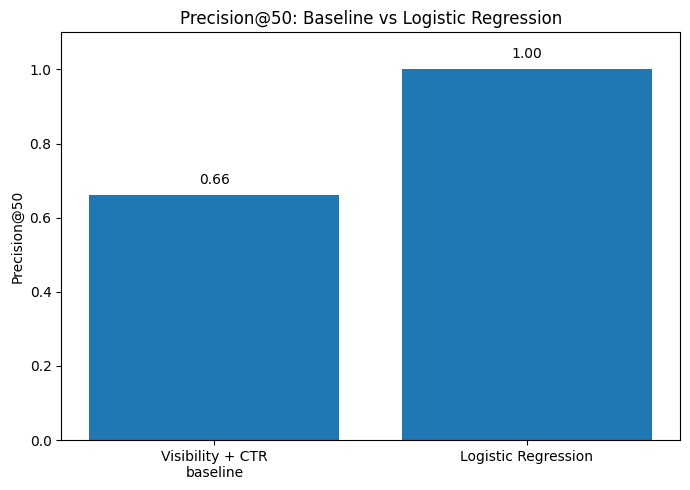

Chart saved to: work/outputs/capstone_precision_at_50.png


In [14]:
# Create the results table and Precision@50 chart.

import os
import pandas as pd
import matplotlib.pyplot as plt

# Make sure the output directory exists
OUTPUT_DIR = "work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# 1. Results summary table
# -----------------------------

results_table = pd.DataFrame({
    "Method": [
        "Visibility + CTR baseline",
        "Logistic Regression"
    ],
    "Precision@50": [
        0.66,
        1.00
    ],
    "Correct in Top 50": [
        "33 / 50",
        "50 / 50"
    ]
})

print("Results summary:")
display(results_table)

# -----------------------------
# 2. Precision@50 chart
# -----------------------------

methods = [
    "Visibility + CTR\nbaseline",
    "Logistic Regression"
]

precision_values = [
    0.66,
    1.00
]

plt.figure(figsize=(7, 5))
bars = plt.bar(methods, precision_values)

plt.ylabel("Precision@50")
plt.title("Precision@50: Baseline vs Logistic Regression")
plt.ylim(0, 1.1)

for bar, value in zip(bars, precision_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()

# Save artifact
CHART_PATH = os.path.join(
    OUTPUT_DIR,
    "capstone_precision_at_50.png"
)

plt.savefig(CHART_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("Chart saved to:", CHART_PATH)

# -----------------------------
# Checks
# -----------------------------

assert len(results_table) == 2
assert results_table["Precision@50"].tolist() == [0.66, 1.00]
assert os.path.exists(CHART_PATH)

## ML-12 — Closing Deliverables

### 1. 5-Minute Demo Outline

**1. Problem — 1 minute**
- SEO/content teams need to prioritize which pages should be reviewed first.
- The goal is decision-support, not automatic refresh decisions.

**2. Data & Task — 1 minute**
- One row represents one content page.
- The target proxy is `trend_direction == "down"`.
- The task is binary classification and ranking.
- The main metric is Precision@50.

**3. Method — 1 minute**
- Compare a Visibility + CTR baseline with Logistic Regression.
- Use a client-level grouped train/test split.
- Hold out 7 clients for testing with zero client overlap.

**4. Results — 1 minute**
- Baseline Precision@50: **0.66 (33/50)**
- Logistic Regression Precision@50: **1.00 (50/50)**
- The result is measured on the same held-out client test set.

**5. Interpretation & Limitations — 1 minute**
- The model provides a ranked review queue.
- High-scoring pages still require human investigation.
- The proxy label is not a causal measure of refresh opportunity.
- The result should be re-evaluated on future data and additional context.

---

### 2. Social-Post Cut

I built an ML-based content opportunity scoring workflow for SEO review prioritization. Using a client-level held-out evaluation, Logistic Regression achieved **1.00 Precision@50**, compared with **0.66** for the Visibility + CTR baseline. The result is a decision-support ranking, not a claim about causality or Google's ranking algorithm.

---

### 3. 3-Sentence Employer-Facing Summary

I built an interpretable Logistic Regression model to rank content pages for SEO review using observable performance and content signals. I evaluated it against a simple Visibility + CTR baseline using a client-level holdout, where the model achieved **1.00 Precision@50 versus 0.66 for the baseline** on the held-out test set. I also performed signal auditing, leakage checks, error analysis, and documented limitations so the result could be used as a research-oriented decision-support workflow rather than an automatic refresh recommendation.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
